# GBM Library Benchmark: sklearn vs XGBoost vs LightGBM vs CatBoost

**Docker image**: `ml4t-gpu`

**Chapter 12, Section 12.2**: The Workhorse - Gradient Boosting Machines

## Purpose
This notebook benchmarks four gradient boosting implementations across CPU and
GPU, measuring accuracy (IC), training time, and memory consumption. The goal
is to provide practitioners with concrete data for library selection rather
than relying on conventional wisdom.

## Learning Objectives
- Compare sklearn HistGradientBoosting, XGBoost, LightGBM, and CatBoost
- Measure GPU speedup on a real financial dataset
- Understand how model complexity (light/medium/heavy presets) affects the
  accuracy–speed–memory tradeoff
- Demonstrate monotonic constraints and SHAP dependence analysis

## Cross-References
- **Section 12.2**: Library comparison and GPU training discussion
- **Related**: `04_optuna_tuning` for hyperparameter optimization
- **Related**: `08_shap_analysis` for SHAP fundamentals

In [1]:
"""GBM Library Benchmark - compare sklearn, XGBoost, LightGBM and CatBoost on accuracy, speed and memory."""

# Import torch before ml4t.diagnostic, which transitively dlopens the older system
# `libcudart.so.12` and wins symbol resolution; a torch import after that fails on
# `undefined symbol: cudaGetDriverEntryPointByVersion`.
import gc
import os
import subprocess
import time
import warnings
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import psutil
import torch  # noqa: F401
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from sklearn.metrics import ndcg_score

from case_studies.utils.gbm import (
    create_model,
    load_gbm_config,
)

# LightGBM records synthetic feature names when fitted on an array with an eval_set,
# and sklearn then warns at every predict on an array that has none to compare. One
# message, not the category: the fit and the predictions are unaffected.
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
    module="sklearn.utils.validation",
)


def cross_sectional_ic_mean(y_true, y_pred, dates, symbols):
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


from utils.modeling import load_modeling_dataset
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLOR_CYCLER, show_with_alt

# One colour per library, shared across the CPU and GPU figures. COLOR_CYCLER's first
# four entries separate perceptually; blue, slate and neutral all read as near-navy and
# are indistinguishable in a grouped bar chart.
LIB_COLORS = {
    "sklearn_hgb": COLOR_CYCLER[0],  # navy
    "xgboost": COLOR_CYCLER[1],  # gold
    "lightgbm": COLOR_CYCLER[2],  # copper
    "catboost": COLOR_CYCLER[3],  # green
}


def report_no_gpu(section: str) -> None:
    """Say a GPU section produced nothing, so an empty section reads as an absence."""
    display(
        Markdown(
            f"**{section}**: no GPU was detected in this run, so this "
            "section is empty. The prose above describes what it measures."
        )
    )

### GPU Detection
Probe NVIDIA GPU availability and test each GBM library's GPU backend.
This determines which benchmark configurations to include.

In [2]:
def detect_gpu_capabilities() -> dict[str, Any]:
    """Detect available GPU backends for each GBM library.

    Probes NVIDIA GPU via nvidia-smi, then tests tiny fits for each library.
    """
    caps: dict[str, Any] = {
        "has_nvidia": False,
        "gpu_name": "none",
        "gpu_vram_mb": 0,
        "xgboost_cuda": False,
        "lightgbm_cuda": False,
        "catboost_gpu": False,
    }

    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
            capture_output=True,
            text=True,
            timeout=5,
        )
        if out.returncode == 0:
            parts = out.stdout.strip().split(", ")
            caps["has_nvidia"] = True
            caps["gpu_name"] = parts[0]
            caps["gpu_vram_mb"] = int(parts[1]) if len(parts) > 1 else 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass

    if caps["has_nvidia"]:
        _X = np.random.randn(20, 3).astype(np.float32)
        _y = np.random.randn(20).astype(np.float32)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                import xgboost as xgb

                xgb.XGBRegressor(
                    n_estimators=2, device="cuda", tree_method="hist", verbosity=0
                ).fit(_X, _y)
                caps["xgboost_cuda"] = True
            except Exception:
                pass
            try:
                import lightgbm as lgb

                lgb.LGBMRegressor(n_estimators=2, device="cuda", verbose=-1).fit(_X, _y)
                caps["lightgbm_cuda"] = True
            except Exception:
                pass
            try:
                import catboost as cb

                cb.CatBoostRegressor(
                    iterations=2, task_type="GPU", verbose=0, allow_writing_files=False
                ).fit(_X, _y)
                caps["catboost_gpu"] = True
            except Exception:
                pass

    return caps

In [3]:
CASE_STUDY = "etfs"
LABEL = "fwd_ret_21d"
# 0 = all symbols
MAX_SYMBOLS = 0
SEED = 42
# Cap parallelism to mirror a representative reader machine. All libraries
# are forced to N_JOBS threads; this also requires invoking with
# OMP_NUM_THREADS=N_JOBS so sklearn_hgb's OpenMP path is bounded too.
N_JOBS = 8

In [4]:
set_global_seeds(SEED)

In [5]:
CHAPTER_DIR = get_chapter_dir(12)
OUTPUT_DIR = CHAPTER_DIR / "output" / "benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. GPU Detection

We probe the system for GPU availability. XGBoost and LightGBM use CUDA
directly; CatBoost has its own GPU backend. sklearn does not support GPU.

In [6]:
gpu_caps = detect_gpu_capabilities()

gpu_info = pl.DataFrame([{"capability": k, "value": str(v)} for k, v in gpu_caps.items()])
gpu_info

[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


capability,value
str,str
"""has_nvidia""","""True"""
"""gpu_name""","""NVIDIA GeForce RTX 3090"""
"""gpu_vram_mb""","""24576"""
"""xgboost_cuda""","""True"""
"""lightgbm_cuda""","""False"""
"""catboost_gpu""","""True"""


In [7]:
HAS_GPU = gpu_caps.get("has_nvidia", False)
GPU_LIBRARIES = []
if HAS_GPU:
    if gpu_caps.get("xgboost_cuda"):
        GPU_LIBRARIES.append("xgboost")
    if gpu_caps.get("lightgbm_cuda"):
        GPU_LIBRARIES.append("lightgbm")
    if gpu_caps.get("catboost_gpu"):
        GPU_LIBRARIES.append("catboost")

print(f"GPU available: {HAS_GPU}")
if HAS_GPU:
    print(f"GPU name: {gpu_caps.get('gpu_name', 'unknown')}")
    print(f"GPU-capable libraries (CUDA only): {GPU_LIBRARIES}")
else:
    print("No NVIDIA GPU detected; running the CPU-only benchmark")

GPU available: True
GPU name: NVIDIA GeForce RTX 3090
GPU-capable libraries (CUDA only): ['xgboost', 'catboost']


## 2. Load Benchmark Data

We use the ETF dataset (99 symbols, ~251K rows, 71 features) as the benchmark
target. A single walk-forward fold avoids CV overhead while producing a
realistic train/test split.

In [8]:
mds = load_modeling_dataset(CASE_STUDY, LABEL, max_symbols=MAX_SYMBOLS)
split = mds.splits[0]  # First fold only
df = mds.dataset.to_pandas()
date_col = mds.date_col
FEATURE_COLS = mds.feature_names

train_mask = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
test_mask = (df[date_col] >= split["val_start"]) & (df[date_col] <= split["val_end"])

primary_entity_col = mds.entity_cols[0]

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, mds.label_col].values
X_test = df.loc[test_mask, FEATURE_COLS].values
y_test = df.loc[test_mask, mds.label_col].values
dates_train = df.loc[train_mask, date_col].values
symbols_train = df.loc[train_mask, primary_entity_col].values
dates_test = df.loc[test_mask, date_col].values
symbols_test = df.loc[test_mask, primary_entity_col].values

# Drop NaN labels
train_valid = np.isfinite(y_train)
test_valid = np.isfinite(y_test)
X_train, y_train = X_train[train_valid], y_train[train_valid]
X_test, y_test = X_test[test_valid], y_test[test_valid]
dates_train, symbols_train = dates_train[train_valid], symbols_train[train_valid]
dates_test, symbols_test = dates_test[test_valid], symbols_test[test_valid]

print(f"Dataset: {CASE_STUDY}")
print(
    f"  Train: {len(X_train):,} rows ({str(split['train_start'])[:10]} → {str(split['train_end'])[:10]})"
)
print(
    f"  Test:  {len(X_test):,} rows ({str(split['val_start'])[:10]} → {str(split['val_end'])[:10]})"
)
print(f"  Features: {len(FEATURE_COLS)}")

Dataset: etfs
  Train: 165,185 rows (2006-01-13 → 2015-11-24)
  Test:  22,184 rows (2015-12-28 → 2016-12-23)
  Features: 71


## 3. Benchmark Infrastructure

We define the benchmark grid: 4 libraries × 3 presets × {CPU, GPU}.
Memory is tracked via RSS delta (process resident memory before/after training).

In [9]:
def get_rss_mb() -> float:
    """Current process RSS in MB."""
    return psutil.Process().memory_info().rss / 1e6

In [10]:
CPU_LIBRARIES = ["sklearn_hgb", "xgboost", "lightgbm", "catboost"]
PRESET_NAMES = ["light", "medium", "heavy"]

# Build benchmark grid
benchmark_grid = []
for preset in PRESET_NAMES:
    for lib in CPU_LIBRARIES:
        benchmark_grid.append({"library": lib, "preset": preset, "device": "cpu"})
    if HAS_GPU:
        for lib in GPU_LIBRARIES:
            benchmark_grid.append({"library": lib, "preset": preset, "device": "cuda"})

n_cpu = sum(1 for r in benchmark_grid if r["device"] == "cpu")
n_gpu = sum(1 for r in benchmark_grid if r["device"] == "cuda")
print(f"Benchmark grid: {len(benchmark_grid)} configurations ({n_cpu} CPU + {n_gpu} GPU)")

# Show preset configurations
for name in PRESET_NAMES:
    cfg = load_gbm_config(name)
    print(f"  {name:8s}: {cfg['n_trees']} trees, depth={cfg['max_depth']}, lr={cfg['lr']}")

Benchmark grid: 18 configurations (12 CPU + 6 GPU)
  light   : 200 trees, depth=4, lr=0.1
  medium  : 500 trees, depth=6, lr=0.05
  heavy   : 1000 trees, depth=8, lr=0.01


## 4. Run Benchmark

Each configuration trains on the full training set and predicts on the test
set. We record IC, wall-clock training time, and RSS memory delta.

In [11]:
results = []

for i, run in enumerate(benchmark_grid):
    lib, preset, device = run["library"], run["preset"], run["device"]
    config = load_gbm_config(preset)
    label = f"{lib}/{preset}/{device}"

    # Create model and cap parallelism to N_JOBS across libraries
    model = create_model(lib, config, device=device)
    if lib in ("xgboost", "lightgbm"):
        model.set_params(n_jobs=N_JOBS)
    elif lib == "catboost":
        model.set_params(thread_count=N_JOBS)
    # sklearn_hgb honours OMP_NUM_THREADS (set in the run environment)

    # Force garbage collection before measuring memory
    gc.collect()
    rss_before = get_rss_mb()

    # Train and time
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    rss_after = get_rss_mb()
    mem_delta = max(0, rss_after - rss_before)

    # Predict and time (separate from IC computation so we measure raw inference)
    # First call is a warm-up to amortise any first-prediction allocations;
    # second call is the timed measurement. Throughput reported in rows/sec.
    _ = model.predict(X_test[: min(1024, len(X_test))])
    t1 = time.perf_counter()
    y_pred_test = model.predict(X_test)
    predict_test_elapsed = time.perf_counter() - t1
    t2 = time.perf_counter()
    y_pred_train = model.predict(X_train)
    predict_train_elapsed = time.perf_counter() - t2

    train_ic = cross_sectional_ic_mean(y_train, y_pred_train, dates_train, symbols_train)
    test_ic = cross_sectional_ic_mean(y_test, y_pred_test, dates_test, symbols_test)

    predict_throughput = (
        len(X_test) / predict_test_elapsed if predict_test_elapsed > 0 else float("nan")
    )

    results.append(
        {
            "library": lib,
            "preset": preset,
            "device": device,
            "test_ic": round(test_ic, 4),
            "train_ic": round(train_ic, 4),
            "time_s": round(elapsed, 2),
            "predict_test_s": round(predict_test_elapsed, 4),
            "predict_train_s": round(predict_train_elapsed, 4),
            "predict_rows_per_s": round(predict_throughput, 0),
            "mem_mb": round(mem_delta, 0),
            "n_trees": config["n_trees"],
        }
    )

    print(
        f"  [{i + 1:2d}/{len(benchmark_grid)}] {label:35s}  IC={test_ic:+.4f}  "
        f"fit={elapsed:6.2f}s  pred={predict_test_elapsed:.4f}s ({predict_throughput / 1e3:5.1f}k rows/s)  {mem_delta:5.0f} MB"
    )

    # Free model to avoid memory accumulation
    del model
    gc.collect()

print(f"\nCompleted {len(results)} benchmark runs")

  [ 1/18] sklearn_hgb/light/cpu                IC=-0.0190  fit=  0.79s  pred=0.0224s (988.6k rows/s)     31 MB


  [ 2/18] xgboost/light/cpu                    IC=-0.0670  fit=  1.65s  pred=0.0044s (5009.3k rows/s)     87 MB


  [ 3/18] lightgbm/light/cpu                   IC=-0.0180  fit=  0.99s  pred=0.0162s (1366.4k rows/s)    178 MB


  [ 4/18] catboost/light/cpu                   IC=-0.0113  fit=  1.15s  pred=0.0085s (2604.3k rows/s)    112 MB


  [ 5/18] xgboost/light/cuda                   IC=+0.0259  fit=  0.61s  pred=0.0112s (1987.8k rows/s)      0 MB


...

  [14/18] xgboost/heavy/cpu                    IC=-0.0431  fit= 18.69s  pred=0.0715s (310.2k rows/s)     27 MB


  [15/18] lightgbm/heavy/cpu                   IC=-0.0193  fit=  8.92s  pred=0.3186s ( 69.6k rows/s)     10 MB


  [16/18] catboost/heavy/cpu                   IC=-0.0429  fit= 23.50s  pred=0.0068s (3259.5k rows/s)     50 MB


  [17/18] xgboost/heavy/cuda                   IC=-0.0349  fit=  4.98s  pred=0.0169s (1315.6k rows/s)     14 MB


  [18/18] catboost/heavy/cuda                  IC=-0.0199  fit=  4.20s  pred=0.0057s (3870.9k rows/s)      0 MB

Completed 18 benchmark runs


In [12]:
# Save raw benchmark results
results_df = pl.DataFrame(results)
benchmark_path = OUTPUT_DIR / "gbm_benchmark.parquet"
results_df.write_parquet(benchmark_path)
# Print a repo-relative path so the notebook output carries no machine- or
# container-absolute path (e.g. /app/... under Docker).
print(f"Saved benchmark results to {benchmark_path.relative_to(CHAPTER_DIR.parent)}")

Saved benchmark results to 12_gradient_boosting/output/benchmark/gbm_benchmark.parquet


## 5. Accuracy Results (IC)

Test-set IC by library, preset and device. On one fold, a difference of this size
is not a difference: nothing here carries an interval, so read the table for the
sign and the spread rather than for an ordering.

In [13]:
# IC pivot: library × preset, CPU only
ic_cpu = (
    results_df.filter(pl.col("device") == "cpu")
    .pivot(on="library", index="preset", values="test_ic")
    .sort("preset")
)
ic_cpu

preset,sklearn_hgb,xgboost,lightgbm,catboost
str,f64,f64,f64,f64
"""heavy""",-0.0669,-0.0431,-0.0193,-0.0429
"""light""",-0.019,-0.067,-0.018,-0.0113
"""medium""",-0.0333,-0.0461,0.0046,-0.0324


In [14]:
if HAS_GPU:
    # IC comparison: CPU vs GPU for each library
    ic_device = (
        results_df.filter(pl.col("library").is_in(GPU_LIBRARIES))
        .pivot(on="device", index=["library", "preset"], values="test_ic")
        .sort(["library", "preset"])
    )
    from IPython.display import display

    display(ic_device)

library,preset,cpu,cuda
str,str,f64,f64
"""catboost""","""heavy""",-0.0429,-0.0199
"""catboost""","""light""",-0.0113,-0.0281
"""catboost""","""medium""",-0.0324,-0.0241
"""xgboost""","""heavy""",-0.0431,-0.0349
"""xgboost""","""light""",-0.067,0.0259
"""xgboost""","""medium""",-0.0461,-0.0337


**Interpretation**: on a single walk-forward fold of the ETF universe, every
library and preset lands at a negative test IC; the table above gives the range.
That is not a judgement on the GBM family. It is what an untuned 21-day return
regression on noisy ETF features does out of sample, which is the assumption
under test here.
The benchmark is informative for *engineering* (timing, memory, GPU behavior
below); accuracy claims should be made on multi-fold CV with tuned hyper-
parameters (notebook `04_optuna_tuning`). CPU and GPU versions of the same
library can produce different predictions due to floating-point precision
(GPU histogram binning typically uses FP32), so the IC differences between
CPU and CUDA columns above illustrate this and are not implementation bugs.

## 6. Training Time Results

Wall-clock training time reveals hardware and algorithmic efficiency.
LightGBM's histogram method is typically fastest on CPU at moderate
thread counts; GPU provides the largest speedup for CatBoost and
XGBoost on larger tree counts.

In [15]:
# Time pivot: library × preset, CPU
time_cpu = (
    results_df.filter(pl.col("device") == "cpu")
    .pivot(on="library", index="preset", values="time_s")
    .sort("preset")
)
time_cpu

preset,sklearn_hgb,xgboost,lightgbm,catboost
str,f64,f64,f64,f64
"""heavy""",8.29,18.69,8.92,23.5
"""light""",0.79,1.65,0.99,1.15
"""medium""",3.28,5.53,2.38,4.82


**CPU-thread setup.** Every model is constructed with `N_JOBS=8`
(`n_jobs=8` for XGBoost/LightGBM, `thread_count=8` for CatBoost) and the
script is invoked with `OMP_NUM_THREADS=8` so the scikit-learn
HistGradientBoosting path is bounded too. Eight threads is a
representative reader machine; per-tree split decisions are independent
of thread count, only wall times move.

In [16]:
if HAS_GPU:
    # GPU speedup ratios
    cpu_times = results_df.filter(
        (pl.col("device") == "cpu") & pl.col("library").is_in(GPU_LIBRARIES)
    ).select(["library", "preset", "time_s"])

    gpu_times = results_df.filter(pl.col("device") == "cuda").select(
        ["library", "preset", pl.col("time_s").alias("gpu_time_s")]
    )

    speedup = cpu_times.join(gpu_times, on=["library", "preset"]).with_columns(
        speedup=pl.col("time_s") / pl.col("gpu_time_s")
    )
    from IPython.display import display

    display(speedup)

library,preset,time_s,gpu_time_s,speedup
str,str,f64,f64,f64
"""xgboost""","""light""",1.65,0.61,2.704918
"""catboost""","""light""",1.15,0.49,2.346939
"""xgboost""","""medium""",5.53,1.54,3.590909
"""catboost""","""medium""",4.82,1.43,3.370629
"""xgboost""","""heavy""",18.69,4.98,3.753012
"""catboost""","""heavy""",23.5,4.2,5.595238


## 7. Prediction Speed

Inference latency matters in two production settings: walk-forward backtesting
(millions of predict calls across folds) and live trading (per-bar latency at
rebalance). We report wall-clock `predict()` time on the held-out test set and
the equivalent rows-per-second throughput, separately for CPU and GPU.

In [17]:
# Prediction time pivot: library × preset, CPU
predict_cpu = (
    results_df.filter(pl.col("device") == "cpu")
    .pivot(on="library", index="preset", values="predict_test_s")
    .sort("preset")
)
predict_cpu

preset,sklearn_hgb,xgboost,lightgbm,catboost
str,f64,f64,f64,f64
"""heavy""",0.2345,0.0715,0.3186,0.0068
"""light""",0.0224,0.0044,0.0162,0.0085
"""medium""",0.0939,0.0184,0.0763,0.0041


In [18]:
# Prediction throughput in rows per second, which compares across presets.
throughput_cpu = (
    results_df.filter(pl.col("device") == "cpu")
    .pivot(on="library", index="preset", values="predict_rows_per_s")
    .sort("preset")
)
throughput_cpu

preset,sklearn_hgb,xgboost,lightgbm,catboost
str,f64,f64,f64,f64
"""heavy""",94605.0,310219.0,69631.0,3.259532e6
"""light""",988554.0,5.009337e6,1.366432e6,2.604267e6
"""medium""",236271.0,1.207239e6,290585.0,5.409199e6


In [19]:
if not HAS_GPU:
    report_no_gpu("CPU against GPU prediction speed")
else:
    # Prediction speedup for the libraries that ship a GPU build.
    cpu_pred = results_df.filter(
        (pl.col("device") == "cpu") & pl.col("library").is_in(GPU_LIBRARIES)
    ).select(["library", "preset", pl.col("predict_test_s").alias("cpu_predict_s")])
    gpu_pred = results_df.filter(pl.col("device") == "cuda").select(
        ["library", "preset", pl.col("predict_test_s").alias("gpu_predict_s")]
    )
    predict_speedup = cpu_pred.join(gpu_pred, on=["library", "preset"]).with_columns(
        speedup=pl.col("cpu_predict_s") / pl.col("gpu_predict_s")
    )
    from IPython.display import display

    display(predict_speedup)

library,preset,cpu_predict_s,gpu_predict_s,speedup
str,str,f64,f64,f64
"""xgboost""","""light""",0.0044,0.0112,0.392857
"""catboost""","""light""",0.0085,0.003,2.833333
"""xgboost""","""medium""",0.0184,0.0119,1.546218
"""catboost""","""medium""",0.0041,0.0056,0.732143
"""xgboost""","""heavy""",0.0715,0.0169,4.230769
"""catboost""","""heavy""",0.0068,0.0057,1.192982


**Interpretation**: Prediction speed depends on the number of trees, tree
depth, and the library's inference implementation. CatBoost uses *symmetric
(oblivious) trees* which collapse each prediction to a bitwise path lookup,
making inference deterministic and often the fastest at moderate tree counts.
XGBoost and LightGBM walk asymmetric trees and have similar CPU inference
costs. GPU `predict()` is rarely worth the launch overhead for batch
inference at the row counts of a typical case study, and the speedups above
are smaller than the training speedups in §6 and can be below 1× for small
batches.

## 8. Memory Results

RSS delta (resident memory before vs after `fit`) is a crude lower bound on
training memory: native C/CUDA allocations and memory the allocator has already
reserved or that `gc` reclaims mid-measurement do not show up. At these dataset
sizes the delta is dominated by allocator/gc timing rather than steady-state
model size: most cells read zero and the few non-zero values do not rank presets
or libraries in any stable way. Read this panel as "training here fits
comfortably in a few hundred MB", not as a memory ranking; use a dedicated
profiler (or peak RSS) if you need to size hardware.

In [20]:
mem_cpu = (
    results_df.filter(pl.col("device") == "cpu")
    .pivot(on="library", index="preset", values="mem_mb")
    .sort("preset")
)
mem_cpu

preset,sklearn_hgb,xgboost,lightgbm,catboost
str,f64,f64,f64,f64
"""heavy""",32.0,27.0,10.0,50.0
"""light""",31.0,87.0,178.0,112.0
"""medium""",52.0,1.0,161.0,0.0


## 9. Visualization

Three-panel benchmark summary: accuracy, speed, and memory across all
configurations.

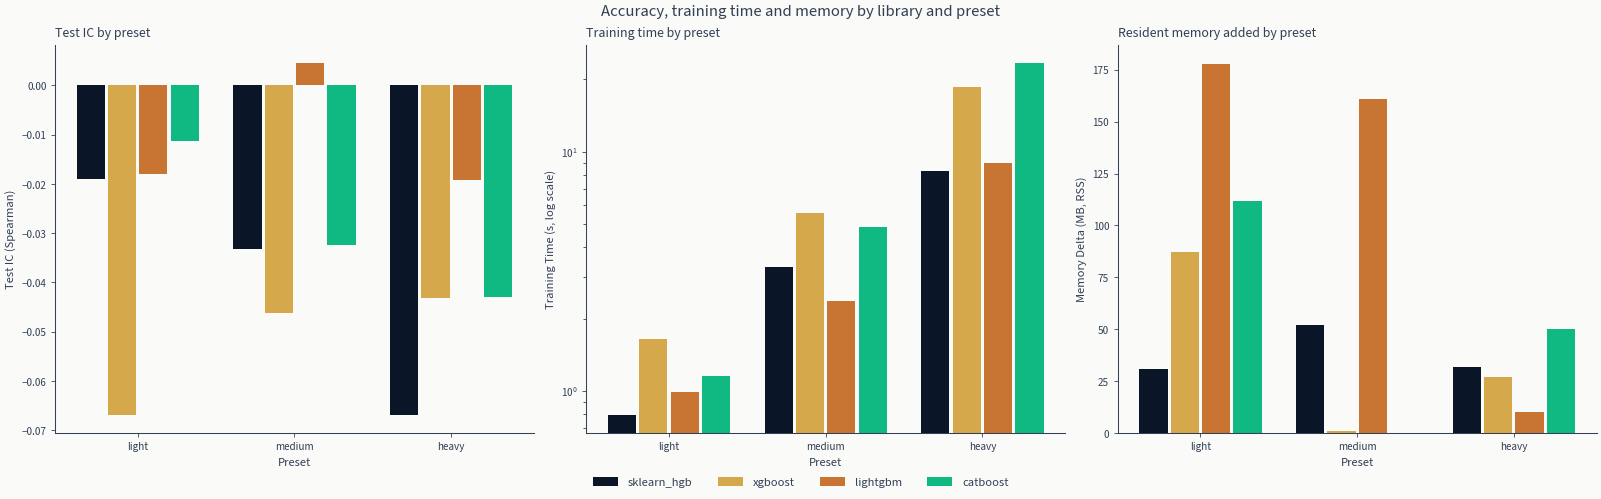

In [21]:
cpu_df = results_df.filter(pl.col("device") == "cpu").to_pandas()
lib_order = CPU_LIBRARIES
preset_order = PRESET_NAMES
colors = LIB_COLORS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel (a): Test IC
for lib in lib_order:
    subset = cpu_df[cpu_df["library"] == lib]
    if subset.empty:
        continue
    x = [preset_order.index(p) for p in subset["preset"]]
    axes[0].bar(
        [xi + lib_order.index(lib) * 0.2 for xi in x],
        subset["test_ic"],
        width=0.18,
        label=lib,
        color=colors[lib],
    )
axes[0].set_xticks([i + 0.3 for i in range(len(preset_order))])
axes[0].set_xticklabels(preset_order)
axes[0].set_xlabel("Preset")
axes[0].set_ylabel("Test IC (Spearman)")
axes[0].set_title("Test IC by preset")

# Training time, log scale.
for lib in lib_order:
    subset = cpu_df[cpu_df["library"] == lib]
    if subset.empty:
        continue
    x = [preset_order.index(p) for p in subset["preset"]]
    axes[1].bar(
        [xi + lib_order.index(lib) * 0.2 for xi in x],
        subset["time_s"],
        width=0.18,
        label=lib,
        color=colors[lib],
    )
axes[1].set_xticks([i + 0.3 for i in range(len(preset_order))])
axes[1].set_xticklabels(preset_order)
axes[1].set_xlabel("Preset")
axes[1].set_ylabel("Training Time (s, log scale)")
axes[1].set_yscale("log")
axes[1].set_title("Training time by preset")

# Panel (c): Memory
for lib in lib_order:
    subset = cpu_df[cpu_df["library"] == lib]
    if subset.empty:
        continue
    x = [preset_order.index(p) for p in subset["preset"]]
    axes[2].bar(
        [xi + lib_order.index(lib) * 0.2 for xi in x],
        subset["mem_mb"],
        width=0.18,
        label=lib,
        color=colors[lib],
    )
axes[2].set_xticks([i + 0.3 for i in range(len(preset_order))])
axes[2].set_xticklabels(preset_order)
axes[2].set_xlabel("Preset")
axes[2].set_ylabel("Memory Delta (MB, RSS)")
axes[2].set_title("Resident memory added by preset")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4, fontsize=9, frameon=False)
fig.suptitle("Accuracy, training time and memory by library and preset", fontsize=12)
show_with_alt(
    fig,
    "Three panels of grouped bars sharing a preset axis, one bar per library. Left: "
    "test rank IC, with the bars measured from zero. Middle: training time in seconds "
    "on a log scale. Right: the resident memory each fit added, in megabytes.",
)

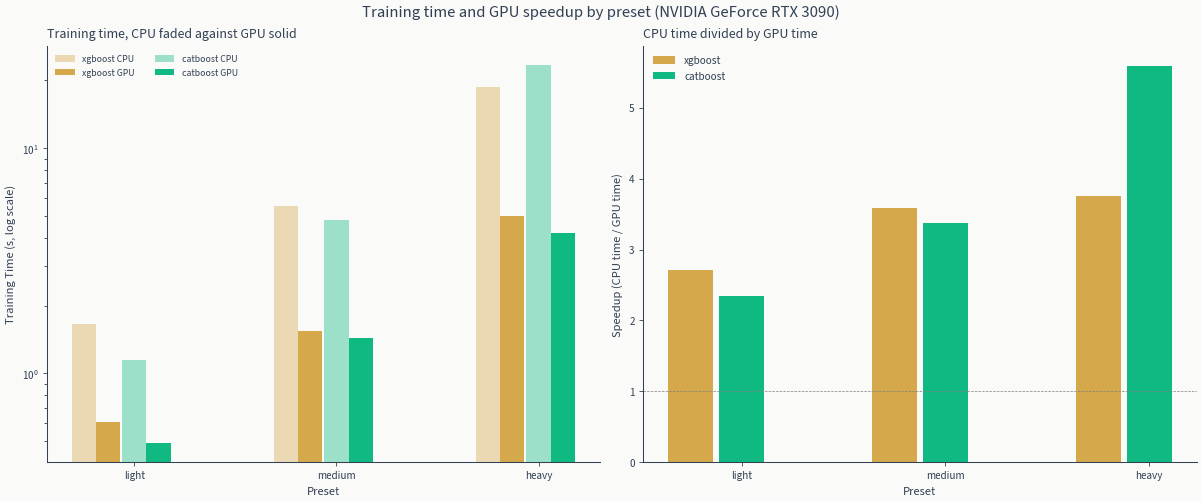

In [22]:
if not HAS_GPU:
    report_no_gpu("CPU against GPU timing")
else:
    gpu_df = results_df.filter(pl.col("device") == "cuda").to_pandas()
    cpu_gpu_libs = GPU_LIBRARIES
    gpu_colors = LIB_COLORS  # same hue per library as the CPU figure

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # CPU against GPU training time.
    for lib in cpu_gpu_libs:
        cpu_sub = cpu_df[(cpu_df["library"] == lib)]
        gpu_sub = gpu_df[(gpu_df["library"] == lib)]
        if cpu_sub.empty and gpu_sub.empty:
            continue
        offset = cpu_gpu_libs.index(lib) * 0.25
        if not cpu_sub.empty:
            x = [preset_order.index(p) for p in cpu_sub["preset"]]
            axes[0].bar(
                [xi + offset for xi in x],
                cpu_sub["time_s"].values,
                width=0.12,
                color=gpu_colors[lib],
                alpha=0.4,
                label=f"{lib} CPU",
            )
        if not gpu_sub.empty:
            x = [preset_order.index(p) for p in gpu_sub["preset"]]
            axes[0].bar(
                [xi + offset + 0.12 for xi in x],
                gpu_sub["time_s"].values,
                width=0.12,
                color=gpu_colors[lib],
                label=f"{lib} GPU",
            )
    axes[0].set_xticks([i + 0.25 for i in range(len(preset_order))])
    axes[0].set_xticklabels(preset_order)
    axes[0].set_xlabel("Preset")
    axes[0].set_ylabel("Training Time (s, log scale)")
    axes[0].set_yscale("log")
    axes[0].set_title("Training time, CPU faded against GPU solid")
    axes[0].legend(fontsize=7, ncol=2)

    # Panel (b): GPU speedup
    speedup_pd = speedup.to_pandas()
    for lib in cpu_gpu_libs:
        sub = speedup_pd[speedup_pd["library"] == lib]
        if sub.empty:
            continue
        x = [preset_order.index(p) for p in sub["preset"]]
        axes[1].bar(
            [xi + cpu_gpu_libs.index(lib) * 0.25 for xi in x],
            sub["speedup"],
            width=0.22,
            label=lib,
            color=gpu_colors[lib],
        )
    axes[1].set_xticks([i + 0.25 for i in range(len(preset_order))])
    axes[1].set_xticklabels(preset_order)
    axes[1].set_xlabel("Preset")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].axhline(y=1, color="gray", linestyle="--", linewidth=0.5)
    axes[1].set_title("CPU time divided by GPU time")
    axes[1].legend(fontsize=8)

    fig.suptitle(
        f"Training time and GPU speedup by preset ({gpu_caps.get('gpu_name', 'GPU')})",
        fontsize=12,
    )
    show_with_alt(
        fig,
        "Two panels sharing a preset axis. Left: training time per library, the CPU bar "
        "faded and the GPU bar solid beside it. Right: the ratio of the two, against a "
        "dashed line at one where neither device is faster.",
    )

## 10. GPU Speedup at Scale

The ETF benchmark above is small enough (227K training rows) that GPU
launch overhead competes with kernel time. We re-run the medium preset
on the US Equities Panel (~5M training rows) to demonstrate how dataset
scale changes the picture. LightGBM's CUDA backend computes in double precision
only: its `gpu_use_dp` toggle "can be used only in OpenCL implementation
(`device_type='gpu'`), in CUDA implementation only double precision is currently
supported" (LightGBM docs). A consumer GPU runs FP64 at a small fraction of its
FP32 throughput, so LightGBM's CUDA path runs and gains far less from the device
than XGBoost or CatBoost.

> **Run this notebook in the `ml4t-gpu` Docker image.** Only that image
> (and `rapids`) ships a LightGBM compiled from source with `-DUSE_CUDA=1`;
> the local `uv` venv installs the PyPI wheel, which is CPU/OpenCL-only and
> has NO CUDA build. Under `uv`, `detect_gpu_capabilities()` reports
> `lightgbm_cuda=False`, the `device=='cuda'` loop skips LightGBM, and its
> GPU rows silently vanish. If the GPU detection panel above does not list
> all three of xgboost/lightgbm/catboost, you are NOT in the CUDA-LightGBM
> image and the GPU numbers are wrong: do not record them.

In [23]:
scale_data_ready = False
if HAS_GPU:
    from utils.modeling import load_modeling_dataset

    try:
        scale_mds = load_modeling_dataset("us_equities_panel", "fwd_ret_1d", max_symbols=0)
    except (FileNotFoundError, ValueError) as exc:
        display(
            Markdown(
                "**Scale benchmark skipped**: it re-runs the medium preset on the "
                "`us_equities_panel` case study, whose artifacts this environment cannot "
                f"use. `{type(exc).__name__}: {str(exc).splitlines()[0][:200]}`. The ETF "
                "benchmark above is unaffected."
            )
        )
    else:
        scale_data_ready = True
        scale_split = scale_mds.splits[0]
        scale_df = scale_mds.dataset.to_pandas()
        scale_date = scale_mds.date_col

        scale_train = (scale_df[scale_date] >= scale_split["train_start"]) & (
            scale_df[scale_date] <= scale_split["train_end"]
        )
        X_scale = scale_df.loc[scale_train, scale_mds.feature_names].values
        y_scale = scale_df.loc[scale_train, scale_mds.label_col].values
        valid_scale = np.isfinite(y_scale)
        X_scale, y_scale = X_scale[valid_scale], y_scale[valid_scale]

        print(f"Scale benchmark: {X_scale.shape[0]:,} rows and {X_scale.shape[1]} features")

**Scale benchmark skipped**: it re-runs the medium preset on the `us_equities_panel` case study, whose artifacts this environment cannot use. `ValueError: Fold-specific temporal artifact is not aligned with the canonical CV splits: fold 0 train: temporal date coverage 0/2499 (0.0%); fold 0 validation: temporal date coverage 0/252 (0.0%); fold 1 train: t`. The ETF benchmark above is unaffected.

In [24]:
if not HAS_GPU:
    report_no_gpu("GPU speedup at scale")
elif not scale_data_ready:
    display(
        Markdown(
            "**No timings**: the scale dataset did not load, so there is nothing here to "
            "benchmark. The cell above says why."
        )
    )
else:
    scale_results = []
    scale_config = load_gbm_config("medium")
    scale_libs = ["xgboost", "lightgbm", "catboost"]

    for lib in scale_libs:
        for device in ["cpu", "cuda"]:
            if device == "cuda" and lib not in GPU_LIBRARIES:
                continue
            model = create_model(lib, scale_config, device=device)
            if lib in ("xgboost", "lightgbm"):
                model.set_params(n_jobs=N_JOBS)
            elif lib == "catboost":
                model.set_params(thread_count=N_JOBS)
            gc.collect()
            t0 = time.perf_counter()
            model.fit(X_scale, y_scale)
            elapsed = time.perf_counter() - t0
            scale_results.append({"library": lib, "device": device, "time_s": round(elapsed, 2)})
            print(f"  {lib:10s} {device:4s}: {elapsed:7.2f}s")
            del model
            gc.collect()

    scale_df_results = pl.DataFrame(scale_results)
    scale_cpu = scale_df_results.filter(pl.col("device") == "cpu").select(
        ["library", pl.col("time_s").alias("cpu_s")]
    )
    scale_gpu = scale_df_results.filter(pl.col("device") == "cuda").select(
        ["library", pl.col("time_s").alias("gpu_s")]
    )
    scale_speedup = scale_cpu.join(scale_gpu, on="library").with_columns(
        speedup=(pl.col("cpu_s") / pl.col("gpu_s"))
    )
    scale_speedup

**No timings**: the scale dataset did not load, so there is nothing here to benchmark. The cell above says why.

**Interpretation**: where this run produced the table above, it is this machine on
this run and nothing more. What
carries beyond it is the reason the three libraries differ, which is
architectural rather than incidental: LightGBM's CUDA backend computes in double
precision only, and a consumer GPU runs FP64 at a small fraction of its FP32
throughput, so LightGBM has the least to gain from the device while often being
the quickest of the three on CPU. Read the ratios as a demonstration of that
shape, not as numbers to quote: they move with load, thread count and hardware.
The smaller ETF panel earlier in the notebook makes the same point from the other
side, where launch overhead competes with kernel time and the ordering is less
stable.

Every CPU row of the scale benchmark runs at `N_JOBS`, the same thread count as the
ETF benchmark above, so the comparison is per-thread work at the row count printed
with the dataset rather than thread oversubscription on a high-core-count machine.

## 11. Monotonic Constraints and SHAP Dependence

Monotonic constraints force the model to respect a directional relationship:
a constrained feature cannot reverse direction. We compare SHAP dependence
plots for the same feature with and without a negative monotonic constraint,
demonstrating that constraints eliminate spurious local reversals while
preserving the overall relationship.

In [25]:
import lightgbm as lgb
import shap

# Train unconstrained model
lgb_free = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    verbose=-1,
    random_state=42,
    n_jobs=N_JOBS,
)
lgb_free.fit(X_train, y_train)

# Find highest-importance feature for constraint demo
importance = np.array(lgb_free.feature_importances_, dtype=float)
constraint_idx = int(np.argmax(importance))
constraint_feature = FEATURE_COLS[constraint_idx]

# Constrained model: negative monotonic on top feature
mc = [0] * len(FEATURE_COLS)
mc[constraint_idx] = -1
lgb_constrained = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    monotone_constraints=mc,
    verbose=-1,
    n_jobs=N_JOBS,
    random_state=42,
)
lgb_constrained.fit(X_train, y_train)

ic_free = cross_sectional_ic_mean(y_test, lgb_free.predict(X_test), dates_test, symbols_test)
ic_con = cross_sectional_ic_mean(y_test, lgb_constrained.predict(X_test), dates_test, symbols_test)
print(f"Feature: {constraint_feature}")
print(f"  Unconstrained IC: {ic_free:.4f}")
print(f"  Constrained IC:   {ic_con:.4f}  (monotone=-1)")

Feature: regime_log_duration
  Unconstrained IC: 0.0506
  Constrained IC:   0.0451  (monotone=-1)


### SHAP Dependence: Constrained vs Unconstrained

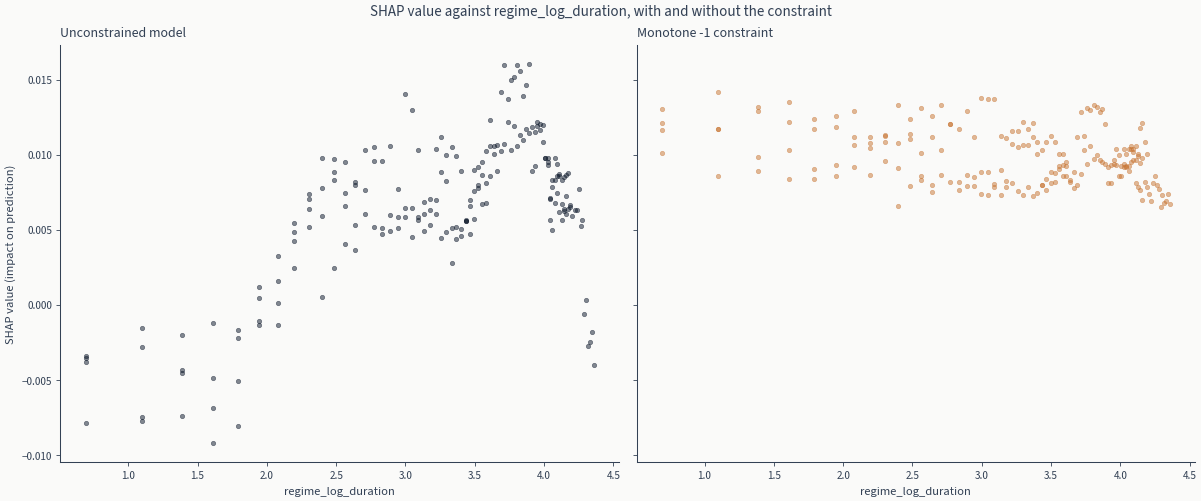

In [26]:
X_sample = X_test[:200]

shap_free = shap.TreeExplainer(lgb_free).shap_values(X_sample)
shap_con = shap.TreeExplainer(lgb_constrained).shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(
    X_sample[:, constraint_idx],
    shap_free[:, constraint_idx],
    alpha=0.5,
    s=10,
    color=COLOR_CYCLER[0],
)
axes[0].set_xlabel(constraint_feature)
axes[0].set_ylabel("SHAP value (impact on prediction)")
axes[0].set_title("Unconstrained model")

axes[1].scatter(
    X_sample[:, constraint_idx],
    shap_con[:, constraint_idx],
    alpha=0.5,
    s=10,
    color=COLOR_CYCLER[2],
)
axes[1].set_xlabel(constraint_feature)
axes[1].set_title("Monotone -1 constraint")

fig.suptitle(f"SHAP value against {constraint_feature}, with and without the constraint")
show_with_alt(
    fig,
    f"Two scatter panels on one vertical scale, SHAP value against {constraint_feature}. "
    "Left, the unconstrained model: points spread over the full height of the axis. "
    "Right, the model fitted with a negative monotone constraint on that feature: the "
    "points sit in a narrow band near the top.",
)

In [27]:
_free_span = float(shap_free[:, constraint_idx].max() - shap_free[:, constraint_idx].min())
_con_span = float(shap_con[:, constraint_idx].max() - shap_con[:, constraint_idx].min())
display(
    Markdown(
        f"- Range of this feature's SHAP values: unconstrained {_free_span:.4f}, "
        f"constrained {_con_span:.4f}.\n"
        f"- Test IC: unconstrained {ic_free:.4f}, constrained {ic_con:.4f}."
    )
)

- Range of this feature's SHAP values: unconstrained 0.0253, constrained 0.0076.
- Test IC: unconstrained 0.0506, constrained 0.0451.

**What to read off it.** Both panels are on one vertical scale, and that is the
comparison. The constrained model has not bent this feature's contribution into a
downward curve; it has flattened it, which satisfies a non-increasing constraint the
cheap way. A monotone prior imposed on a feature whose empirical relationship is
noisy does not force the model to find a monotone signal - it lets the model stop
using the feature's variation, and the range printed above is how far that went.

The two test ICs are close, and on one fold with no interval that is not evidence
either way about the constraint. A directional prior is worth imposing when it is
right, and this notebook cannot tell you whether it is; that needs the constrained
and unconstrained models scored across folds.

## 12. Learning-to-Rank Worked Example (LambdaMART)

The chapter text discusses a ranking objective for cross-sectional stock
selection. We implement a compact LambdaMART workflow using date-wise query
groups and relevance labels derived from forward returns.

In [28]:
rank_cols = [date_col, primary_entity_col, *FEATURE_COLS, mds.label_col]
rank_train_df = df.loc[train_mask, rank_cols].copy().sort_values(date_col)
rank_test_df = df.loc[test_mask, rank_cols].copy().sort_values(date_col)
rank_dates_test = rank_test_df[date_col].values
rank_symbols_test = rank_test_df[primary_entity_col].values

train_finite = np.isfinite(rank_train_df[mds.label_col])
test_finite = np.isfinite(rank_test_df[mds.label_col])
rank_train_df = rank_train_df.loc[train_finite].copy()
rank_test_df = rank_test_df.loc[test_finite].copy()

In [29]:
train_pct = rank_train_df.groupby(date_col)[mds.label_col].rank(method="first", pct=True)
test_pct = rank_test_df.groupby(date_col)[mds.label_col].rank(method="first", pct=True)

rank_train_df["relevance"] = np.minimum((train_pct * 5).astype(int), 4)
rank_test_df["relevance"] = np.minimum((test_pct * 5).astype(int), 4)

X_train_rank = rank_train_df[FEATURE_COLS].values
X_test_rank = rank_test_df[FEATURE_COLS].values
y_train_rel = rank_train_df["relevance"].values
y_test_rel = rank_test_df["relevance"].values
y_train_raw = rank_train_df[mds.label_col].values
y_test_raw = rank_test_df[mds.label_col].values

train_groups = rank_train_df.groupby(date_col).size().to_numpy()
test_groups = rank_test_df.groupby(date_col).size().to_numpy()

print(f"LTR train rows: {len(X_train_rank):,}, groups: {len(train_groups):,}")
print(f"LTR test rows:  {len(X_test_rank):,}, groups: {len(test_groups):,}")

LTR train rows: 165,185, groups: 2,241
LTR test rows:  22,184, groups: 252


In [30]:
rank_train_set = lgb.Dataset(X_train_rank, label=y_train_rel, group=train_groups)
rank_valid_set = lgb.Dataset(
    X_test_rank, label=y_test_rel, group=test_groups, reference=rank_train_set
)

lambdarank_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [10],
    "label_gain": [0, 1, 3, 7, 15],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "verbose": -1,
    "seed": 42,
    "num_threads": N_JOBS,
}

lambdarank_model = lgb.train(
    lambdarank_params,
    rank_train_set,
    num_boost_round=200,
    valid_sets=[rank_valid_set],
)
lambdarank_scores = lambdarank_model.predict(X_test_rank)

# Regression baseline for ranking quality comparison
regression_model = lgb.train(
    {
        "objective": "regression",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.8,
        "verbose": -1,
        "seed": 42,
        "num_threads": N_JOBS,
    },
    lgb.Dataset(X_train_rank, label=y_train_raw),
    num_boost_round=200,
)
regression_scores = regression_model.predict(X_test_rank)

### Mean Group NDCG
Compute mean NDCG@k across query groups for learning-to-rank evaluation.

In [31]:
def mean_group_ndcg(
    y_true_rel: np.ndarray, y_score: np.ndarray, groups: np.ndarray, k: int = 10
) -> float:
    offsets = np.cumsum(np.r_[0, groups])
    ndcg_values = []
    for start, end in zip(offsets[:-1], offsets[1:], strict=False):
        if (end - start) < 2:
            continue
        k_eff = min(k, end - start)
        true_group = y_true_rel[start:end].reshape(1, -1)
        score_group = y_score[start:end].reshape(1, -1)
        ndcg_values.append(ndcg_score(true_group, score_group, k=k_eff))
    return float(np.mean(ndcg_values)) if ndcg_values else np.nan

In [32]:
ltr_summary = pl.DataFrame(
    {
        "model": ["LambdaMART", "GBDT Regression Baseline"],
        "mean_ndcg_at_10": [
            round(mean_group_ndcg(y_test_rel, lambdarank_scores, test_groups), 4),
            round(mean_group_ndcg(y_test_rel, regression_scores, test_groups), 4),
        ],
        "test_ic_vs_raw_return": [
            round(
                cross_sectional_ic_mean(
                    y_test_raw, lambdarank_scores, rank_dates_test, rank_symbols_test
                ),
                4,
            ),
            round(
                cross_sectional_ic_mean(
                    y_test_raw, regression_scores, rank_dates_test, rank_symbols_test
                ),
                4,
            ),
        ],
    }
)
ltr_summary

model,mean_ndcg_at_10,test_ic_vs_raw_return
str,f64,f64
"""LambdaMART""",0.5708,0.0219
"""GBDT Regression Baseline""",0.4857,-0.0449


**Interpretation**: the table above scores each model on both metrics. Note what
the NDCG column can and cannot settle: LambdaMART is trained on a ranking
surrogate and scored with a ranking metric, so an advantage there is the setup
working as arranged rather than a finding. The IC column is the interesting one,
because nothing in the ranking objective asks for a correlation with return
magnitude, and on a single fold the two metrics can agree or disagree by chance.

The choice between them is not decided by either number. Ranking suits top-k
selection within a rebalance, regression suits a signal whose magnitude sizes a
position, and either way the comparison needs multiple folds before it means
anything.

## 13. Key Takeaways

1. **This single-fold benchmark does not rank the libraries on accuracy.** Every
   library and preset lands at a negative test IC on the ETF fold, and the table
   above gives the range. The benchmark is built for engineering questions - timing,
   memory, device behaviour - and an accuracy ordering needs multi-fold CV with tuned
   hyperparameters, which is `04_optuna_tuning`.

2. **What a GPU buys depends on the library, and the reason is architectural.**
   LightGBM's CUDA backend is double-precision only and consumer GPUs run FP64 at a
   fraction of FP32 throughput, so it gains least from the device while often being
   quickest on CPU. The ratios in the tables are this machine on this run; the reason
   they differ is what carries. LightGBM's CUDA path needs the `ml4t-gpu` image at
   all: the PyPI wheel in the local venv has no CUDA build.

3. **CPU and GPU are related but distinct estimators.** Histogram binning at
   different precision changes split points, and those differences cascade through
   the ensemble into IC differences larger than rounding. Do not treat a GPU rerun as
   a reproduction of a CPU result.

4. **The memory panel is a lower bound, and mostly reads zero.** RSS delta is
   dominated by allocator and garbage-collection timing and cannot see native or
   device allocations, so it neither ranks the libraries nor sizes hardware. Use a
   profiler or peak RSS for that; the panel is here to show what the cheap probe does
   and does not capture.

5. **A monotone constraint can be satisfied by flattening a feature.** On the
   highest-importance feature the constrained model's SHAP values collapse into a
   narrow band rather than bending into a downward curve, and the two test ICs are
   close. A directional prior is regularization when the direction is right and a
   silent way of dropping a feature when it is not; one fold cannot tell you which.

6. **A ranking objective and a regression objective answer different questions.**
   The scores are in the table above. LambdaMART's advantage on NDCG is arranged by
   the setup, since it trains on a ranking surrogate and is scored with a ranking
   metric; whether its scores also correlate with return magnitude is the part
   nothing in its objective asks for. Choose ranking for selection within a
   rebalance and regression for a magnitude that sizes a position.

**Next**: See `04_optuna_tuning` for Bayesian hyperparameter optimization,
`08_shap_analysis` for SHAP fundamentals, and `11_conformal_gbm` for
calibrated uncertainty intervals.